# LightGBM Lead-Time Forecasting of Significant Wave Height (Hs) and Mean Wave Period (Te)

This notebook trains LightGBM models to forecast ocean parameters using ERA5 hourly ocean data. 
Targets to forecast:
- **Hs** (Significant Wave Height, corresponding to `swh` in the dataset)
- **Te** (Mean Wave Period, corresponding to `mwp` in the dataset)

Lead steps: 1h, 3h, 6h, 12h, 24h, 48h ahead.

### Step 1: Import Data, Pearson Correlation Matrix, Feature Engineering and Target Preparation

In [13]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Load ERA5 dataset
raw = pd.read_csv("../0_Data_Acquisition/1_ERA5_Data/ERA5_Ocean_2024_01_to_2026_07.csv", parse_dates=["valid_time"])
raw = raw.sort_values("valid_time").reset_index(drop=True)

# Forward-fill missing wave parameters just in case
raw = raw.ffill()

print("Loaded dataset shape:", raw.shape)

Loaded dataset shape: (22477, 20)


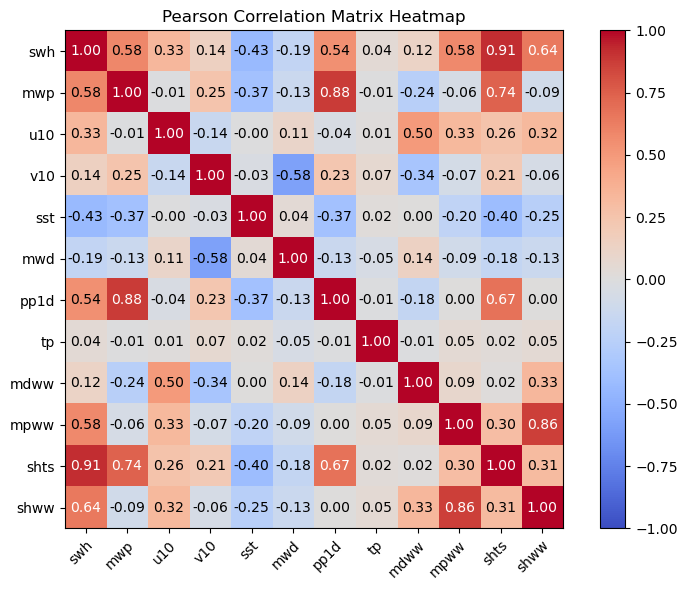

In [14]:
# Pearson Correlation Matrix heatmap using matplotlib
corr_cols = ["swh", "mwp", "u10", "v10", "sst", "mwd", "pp1d", "tp", "mdww", "mpww", "shts", "shww"]
corr_matrix = raw[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols)
ax.set_yticklabels(corr_cols)

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Loop over data dimensions and create text annotations.
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        text = ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                       ha="center", va="center", color="black" if abs(corr_matrix.iloc[i, j]) < 0.6 else "white")

ax.set_title("Pearson Correlation Matrix Heatmap")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [15]:
TARGETS = ["swh", "mwp"]  # swh = Hs, mwp = Te
LEAD_STEPS = [1, 3, 6, 12, 24, 48]  # Lead hours
N_LAGS = [1, 2, 3, 6, 12, 24, 48]

TRAIN_START = pd.Timestamp("2024-01-01 00:00:00")
TRAIN_END = pd.Timestamp("2025-01-01 23:00:00")

VALID_START = pd.Timestamp("2025-01-01 00:00:00")
VALID_END = pd.Timestamp("2026-01-01 23:00:00")

TEST_START = pd.Timestamp("2026-01-01 00:00:00")
TEST_END = pd.Timestamp("2026-07-25 12:00:00")

In [16]:
def build_features(df):
    feat_dict = {}
    feat_dict["hour_sin"] = np.sin(2 * np.pi * df["valid_time"].dt.hour / 24)
    feat_dict["hour_cos"] = np.cos(2 * np.pi * df["valid_time"].dt.hour / 24)
    feat_dict["doy_sin"] = np.sin(2 * np.pi * df["valid_time"].dt.dayofyear / 365.25)
    feat_dict["doy_cos"] = np.cos(2 * np.pi * df["valid_time"].dt.dayofyear / 365.25)
    
    cols_to_lag = [c for c in df.columns if c not in ["valid_time", "latitude", "longitude", "number", "expver", "wmb", "tp"]]
    for col in cols_to_lag:
        feat_dict[col] = df[col]
        for lag in N_LAGS:
            feat_dict[f"{col}_lag{lag}"] = df[col].shift(lag)
            
    return pd.DataFrame(feat_dict, index=df.index)

features_all = build_features(raw)
print(f"Created {features_all.shape[1]} candidate features.")

Created 108 candidate features.


### Step 2: Choosing Training, Validation and Test Sets

In [17]:
def time_masks(t_idx):
    train_mask = (t_idx >= TRAIN_START) & (t_idx <= TRAIN_END)
    valid_mask = (t_idx >= VALID_START) & (t_idx <= VALID_END)
    test_mask = (t_idx >= TEST_START) & (t_idx <= TEST_END)
    return train_mask, valid_mask, test_mask

t_idx = raw["valid_time"]
train_m, valid_m, test_m = time_masks(t_idx)

print(f"Train size: {train_m.sum()} records ({TRAIN_START} to {TRAIN_END})")
print(f"Valid size: {valid_m.sum()} records ({VALID_START} to {VALID_END})")
print(f"Test size: {test_m.sum()} records ({TEST_START} to {TEST_END})")

Train size: 8808 records (2024-01-01 00:00:00 to 2025-01-01 23:00:00)
Valid size: 8784 records (2025-01-01 00:00:00 to 2026-01-01 23:00:00)
Test size: 4933 records (2026-01-01 00:00:00 to 2026-07-25 12:00:00)


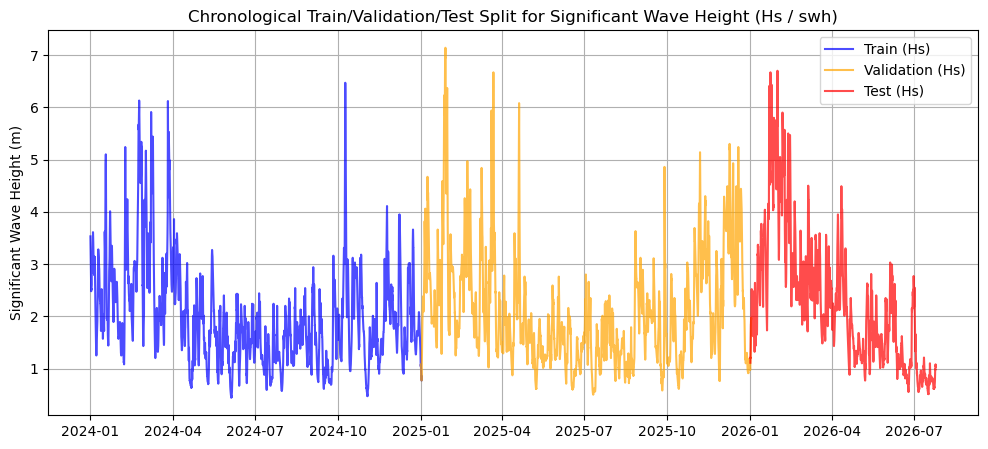

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(t_idx[train_m], raw["swh"][train_m], label="Train (Hs)", color="blue", alpha=0.7)
plt.plot(t_idx[valid_m], raw["swh"][valid_m], label="Validation (Hs)", color="orange", alpha=0.7)
plt.plot(t_idx[test_m], raw["swh"][test_m], label="Test (Hs)", color="red", alpha=0.7)
plt.title("Chronological Train/Validation/Test Split for Significant Wave Height (Hs / swh)")
plt.ylabel("Significant Wave Height (m)")
plt.legend()
plt.grid(True)
plt.show()

### Step 3: Feature Screening and LightGBM Training

In [19]:
def compute_metrics(y_true, pred):
    y_true = np.asarray(y_true)
    pred = np.asarray(pred)
    mse = mean_squared_error(y_true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, pred)
    mape = mean_absolute_percentage_error(y_true, pred) * 100
    nrmse = (rmse / (y_true.max() - y_true.min())) * 100
    r2 = r2_score(y_true, pred)
    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "NRMSE_%": nrmse,
        "MAPE": mape,
        "R2": r2
    }

def screen_features(X, y, top_k=20):
    valid = X.join(y.rename("__target__")).dropna()
    corr = valid.corr()["__target__"].drop("__target__").abs().sort_values(ascending=False)
    return corr.head(top_k)

def fit_with_early_stopping(X_train, y_train, X_valid, y_valid, stopping_rounds=50):
    params = dict(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=0, verbosity=-1)
    model = lgb.LGBMRegressor(**params)
    try:
        model.fit(
            X_train, y_train,
            eval_X=X_valid, eval_y=y_valid,
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=stopping_rounds, verbose=False)],
        )
    except TypeError:
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=stopping_rounds, verbose=False)],
        )
    return model


Training models for target: swh


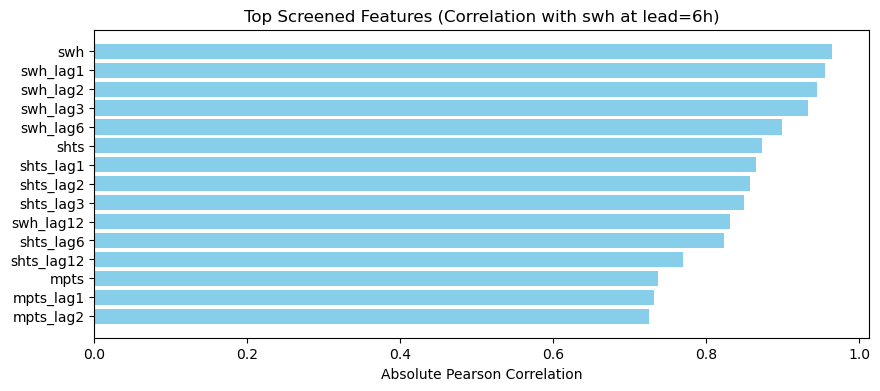

lead=1h  best_iter=300  MAE=0.029  MSE=0.004  RMSE=0.062  NRMSE=1.01%  MAPE=1.18%  R2=0.998
lead=3h  best_iter=295  MAE=0.086  MSE=0.021  RMSE=0.145  NRMSE=2.35%  MAPE=3.75%  R2=0.987
lead=6h  best_iter=223  MAE=0.180  MSE=0.076  RMSE=0.276  NRMSE=4.46%  MAPE=8.23%  R2=0.953
lead=12h  best_iter=104  MAE=0.348  MSE=0.226  RMSE=0.475  NRMSE=7.68%  MAPE=17.07%  R2=0.860
lead=24h  best_iter=97  MAE=0.601  MSE=0.650  RMSE=0.806  NRMSE=13.03%  MAPE=29.61%  R2=0.597
lead=48h  best_iter=63  MAE=0.949  MSE=1.467  RMSE=1.211  NRMSE=19.57%  MAPE=48.45%  R2=0.095

Training models for target: mwp


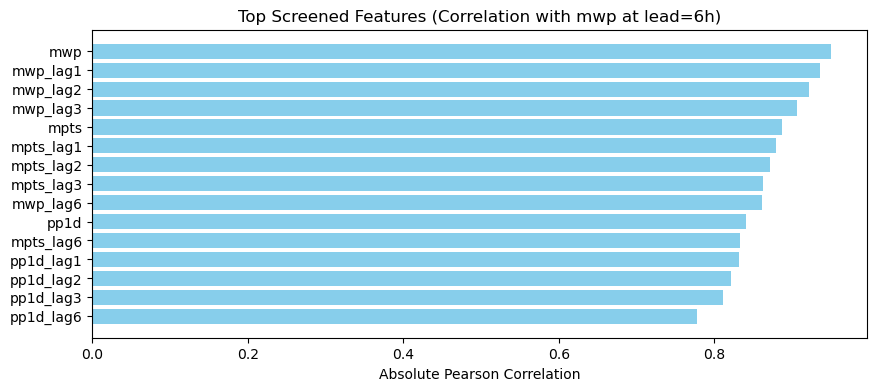

lead=1h  best_iter=294  MAE=0.062  MSE=0.009  RMSE=0.094  NRMSE=0.93%  MAPE=0.74%  R2=0.998
lead=3h  best_iter=298  MAE=0.205  MSE=0.083  RMSE=0.287  NRMSE=2.83%  MAPE=2.43%  R2=0.981
lead=6h  best_iter=292  MAE=0.436  MSE=0.332  RMSE=0.576  NRMSE=5.67%  MAPE=5.20%  R2=0.924
lead=12h  best_iter=69  MAE=0.791  MSE=1.081  RMSE=1.040  NRMSE=10.23%  MAPE=9.20%  R2=0.751
lead=24h  best_iter=43  MAE=1.155  MSE=2.215  RMSE=1.488  NRMSE=14.65%  MAPE=13.10%  R2=0.488
lead=48h  best_iter=34  MAE=1.288  MSE=2.589  RMSE=1.609  NRMSE=15.84%  MAPE=14.60%  R2=0.403


In [20]:
results = []
predictions = {}

for target in TARGETS:
    print(f"\nTraining models for target: {target}")
    ref_lead = 6
    ref_y = raw[target].shift(-ref_lead)
    top_feats_ref = screen_features(features_all, ref_y, top_k=15)
    
    plt.figure(figsize=(10, 4))
    plt.barh(top_feats_ref.index[::-1], top_feats_ref.values[::-1], color="skyblue")
    plt.title(f"Top Screened Features (Correlation with {target} at lead={ref_lead}h)")
    plt.xlabel("Absolute Pearson Correlation")
    plt.show()
    
    for lead in LEAD_STEPS:
        y_target = raw[target].shift(-lead)
        cols = screen_features(features_all, y_target, top_k=108).index.tolist()
        data = features_all[cols].join(y_target.rename("target")).dropna(subset=["target"])
        X, y = data[cols], data["target"]
        t_idx_data = raw.loc[data.index, "valid_time"]
        
        train_mask, valid_mask, test_mask = time_masks(t_idx_data)
        X_train, X_valid, X_test = X[train_mask], X[valid_mask], X[test_mask]
        y_train, y_valid, y_test = y[train_mask], y[valid_mask], y[test_mask]
        
        model = fit_with_early_stopping(X_train, y_train, X_valid, y_valid)
        pred = model.predict(X_test)
        
        metrics = compute_metrics(y_test, pred)
        
        results.append({
            "Target": target,
            "Lead (h)": lead,
            "Best Iteration": model.best_iteration_,
            **metrics
        })
        
        predictions[(target, lead)] = (t_idx_data[test_mask].values, y_test.values, pred)
        print(f"lead={lead}h  best_iter={model.best_iteration_}  " 
              f"MAE={metrics['MAE']:.3f}  MSE={metrics['MSE']:.3f}  RMSE={metrics['RMSE']:.3f}  " 
              f"NRMSE={metrics['NRMSE_%']:.2f}%  MAPE={metrics['MAPE']:.2f}%  R2={metrics['R2']:.3f}")

In [21]:
results_df = pd.DataFrame(results)
print("\nSummary Performance Metrics on Test Set:")
print(results_df.round(4).to_string(index=False))


Summary Performance Metrics on Test Set:
Target  Lead (h)  Best Iteration    MAE    MSE   RMSE  NRMSE_%    MAPE     R2
   swh         1             300 0.0286 0.0039 0.0624   1.0081  1.1755 0.9976
   swh         3             295 0.0857 0.0212 0.1454   2.3497  3.7503 0.9869
   swh         6             223 0.1796 0.0761 0.2759   4.4569  8.2302 0.9527
   swh        12             104 0.3475 0.2257 0.4751   7.6754 17.0669 0.8598
   swh        24              97 0.6013 0.6503 0.8064  13.0279 29.6126 0.5970
   swh        48              63 0.9495 1.4674 1.2114  19.5698 48.4476 0.0949
   mwp         1             294 0.0618 0.0089 0.0944   0.9291  0.7385 0.9980
   mwp         3             298 0.2045 0.0827 0.2875   2.8297  2.4327 0.9810
   mwp         6             292 0.4358 0.3321 0.5762   5.6717  5.2008 0.9237
   mwp        12              69 0.7908 1.0807 1.0396  10.2318  9.2038 0.7510
   mwp        24              43 1.1545 2.2149 1.4882  14.6481 13.1028 0.4885
   mwp        48      

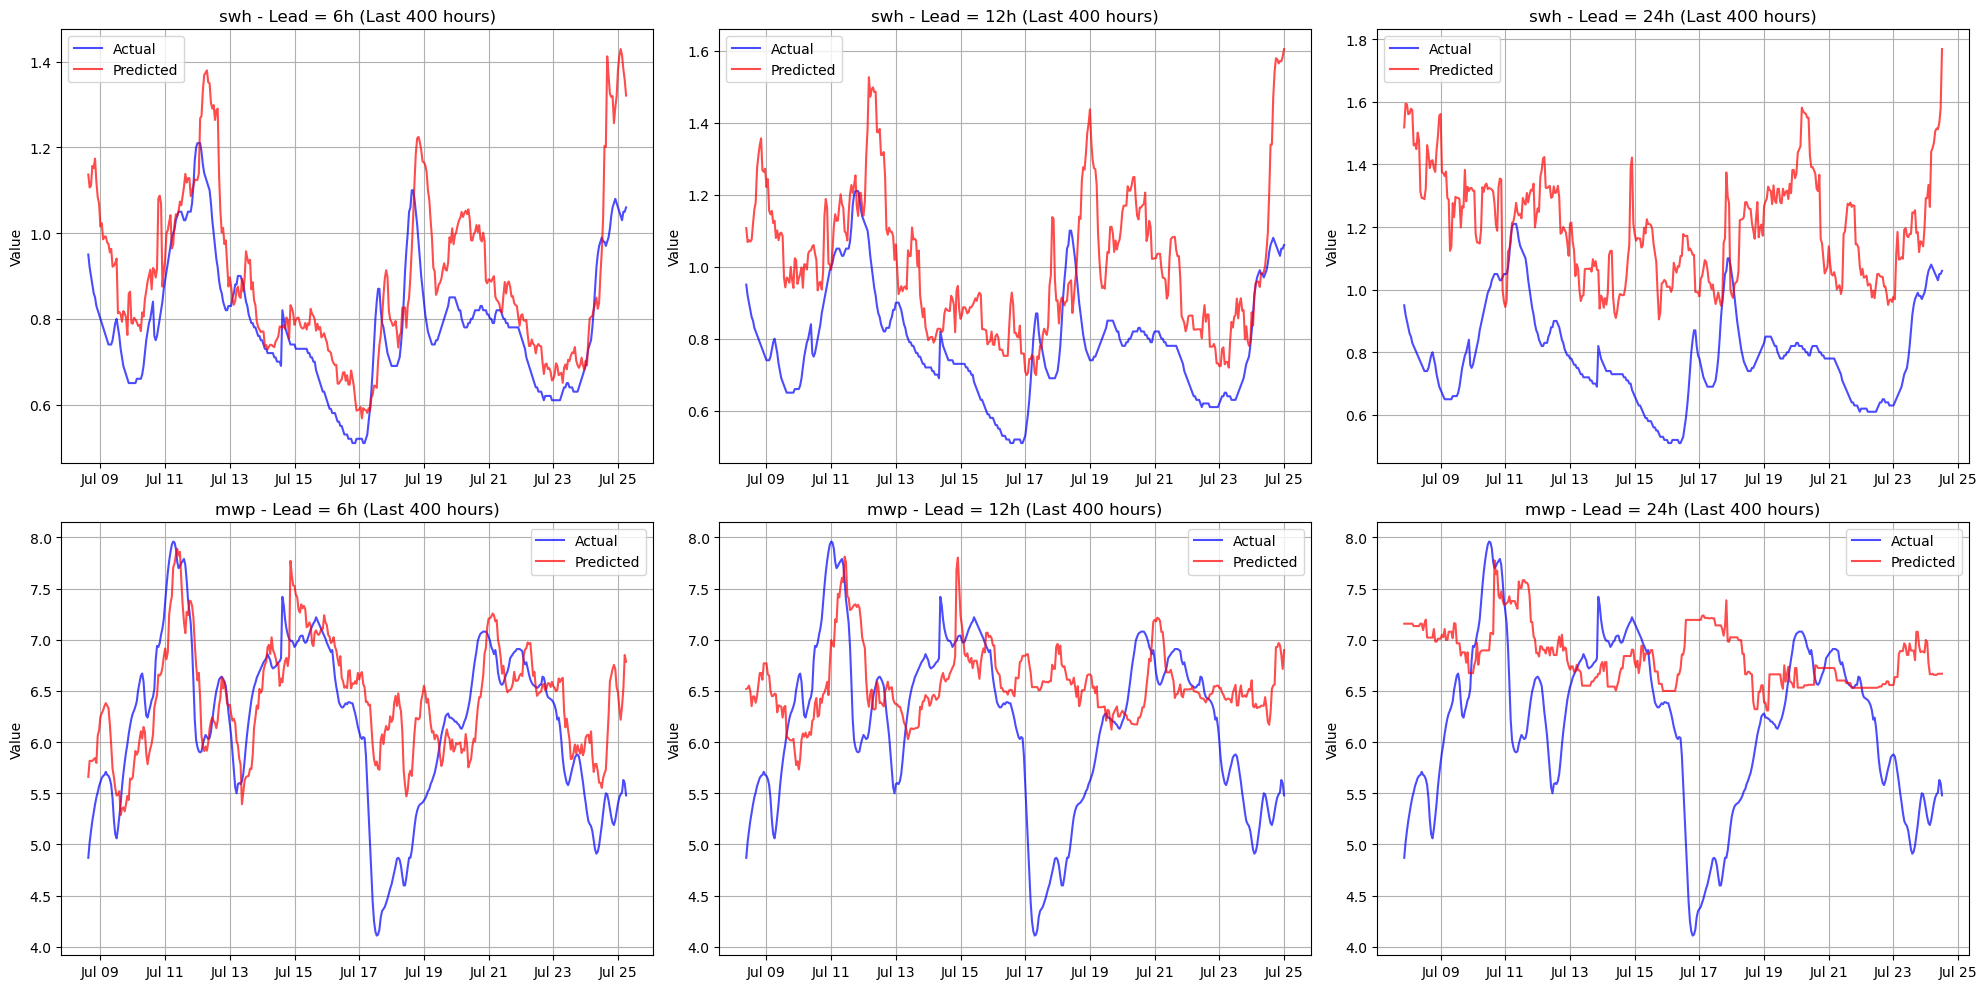

In [22]:
import matplotlib.dates as mdates

plot_leads = [6, 12, 24]
fig, axes = plt.subplots(len(TARGETS), len(plot_leads), figsize=(20, 10), sharex=False)

for i, target in enumerate(TARGETS):
    for j, lead in enumerate(plot_leads):
        tt, actual, pred = predictions[(target, lead)]
        ax = axes[i, j]
        ax.plot(tt[-400:], actual[-400:], label="Actual", color="blue", alpha=0.7)
        ax.plot(tt[-400:], pred[-400:], label="Predicted", color="red", alpha=0.7)
        ax.set_title(f"{target} - Lead = {lead}h (Last 400 hours)")
        ax.set_ylabel("Value")
        
        # Format the X-axis to only show "Month Day" (e.g., "Jul 15")
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        
        ax.grid(True)
        ax.legend()

plt.tight_layout()
plt.show()
